In [ ]:
%load_ext autoreload
%autoreload 2

import os
# import cospar
import scanpy as sc
import PINN 
import numpy as np
import pandas as pd

import palantir
from PINN import tl

import seaborn as sns
import matplotlib.pyplot as plt

os.chdir("/home/wz369/rds/hpc-work/PINN_dynamics")

In [2]:
import anndata as ad
from tqdm.contrib.concurrent import process_map

In [6]:
ad1 = sc.read_h5ad("data/Hiro_Juan_fulldata_20250513.h5ad")
ad1

AnnData object with n_obs × n_vars = 76998 × 33696
    obs: 'library', 'dataset', 'Condition', 'batch', 'day', 'n_genes', 'n_counts', 'percent_mito', 'doublet_score', 'cell_barcode', 'LARRY_barcode', 'Day', 'phase', 'S_score', 'G2M_score', 'leiden', 'LEIDEN', 'cell_type', 'cell_type_2', 'meta_number', 'barcode_rep', 'timepoint_tx_days', 'palantir_pseudotime', 'palantir_entropy', 'split', 'first_t_control'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'isCC', 'mean', 'std'
    uns: 'Condition_colors', 'DM_EigenValues', 'Day_colors', 'LEIDEN_colors', 'cell_type_2_colors', 'cell_type_colors', 'dataset_colors', 'hvg', 'int_vars', 'iroot', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'palantir_waypoints', 'pca', 'phase_colors', 'pop', 'split_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'Delta_DM', 'NB_mean', 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap', 'X_umap_rotated', 'branch_ma

In [41]:
ad1.var_names

Index(['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587',
       'Gm37323', 'Mrpl15', 'A930006A01Rik',
       ...
       'Gm16367', 'ENSMUSG00000094172', 'ENSMUSG00000094887',
       'ENSMUSG00000091585', 'ENSMUSG00000095763', 'ENSMUSG00000095523',
       'ENSMUSG00000095475', 'ENSMUSG00000094855', 'ENSMUSG00000095019',
       'ENSMUSG00000095041'],
      dtype='object', length=33696)

In [12]:
ad2 = sc.read_h5ad("data/Hiro_Juan_fulldata_20250513.h5ad")
ad2

AnnData object with n_obs × n_vars = 76998 × 33696
    obs: 'library', 'dataset', 'Condition', 'batch', 'day', 'n_genes', 'n_counts', 'percent_mito', 'doublet_score', 'cell_barcode', 'LARRY_barcode', 'Day', 'phase', 'S_score', 'G2M_score', 'leiden', 'LEIDEN', 'cell_type', 'cell_type_2', 'meta_number', 'barcode_rep', 'timepoint_tx_days', 'palantir_pseudotime', 'palantir_entropy', 'split', 'first_t_control'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'isCC', 'mean', 'std'
    uns: 'Condition_colors', 'DM_EigenValues', 'Day_colors', 'LEIDEN_colors', 'cell_type_2_colors', 'cell_type_colors', 'dataset_colors', 'hvg', 'int_vars', 'iroot', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'palantir_waypoints', 'pca', 'phase_colors', 'pop', 'split_colors', 'umap'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'Delta_DM', 'NB_mean', 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap', 'X_umap_rotated', 'branch_ma

In [35]:
ad2.obs['Day'].unique()

['3', '6', '8', '10', '13', ..., '17', '22', '24', '27', '28']
Length: 11
Categories (11, object): ['3', '6', '8', '10', ..., '22', '24', '27', '28']

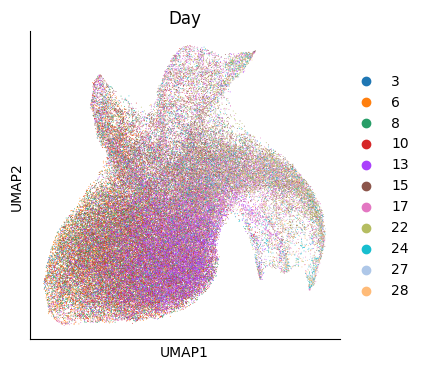

In [23]:
sc.pl.umap(ad2, color='Day')

In [40]:
ad2.var_names

Index(['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587',
       'Gm37323', 'Mrpl15', 'A930006A01Rik',
       ...
       'Gm16367', 'ENSMUSG00000094172', 'ENSMUSG00000094887',
       'ENSMUSG00000091585', 'ENSMUSG00000095763', 'ENSMUSG00000095523',
       'ENSMUSG00000095475', 'ENSMUSG00000094855', 'ENSMUSG00000095019',
       'ENSMUSG00000095041'],
      dtype='object', length=33696)

In [13]:
ad3 = sc.read_h5ad("data/Debi-Hiro_Juan_900_genes_after_Int.h5ad")
ad3

/rds/user/wz369/hpc-work/LIBS/mamba/envs/PINN_env/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 105172 × 986
    obs: 'batch', 'leiden', 'timepoint', 'exp', 'total_counts', 'cell_type', '_scvi_batch', '_scvi_labels'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', 'normed_exp', 'normed_umap'
    layers: 'NB_dispersion', 'NB_mean', 'counts', 'normed_exp'

In [14]:
ad4 = sc.read_h5ad("data/adata_ori_metaclone_20250425_final.h5ad")
ad4

AnnData object with n_obs × n_vars = 179557 × 33696
    obs: 'library', 'dataset', 'sample', 'batch', 'day', 'n_genes', 'n_counts', 'percent_mito', 'doublet_score', 'phase', 'S_score', 'G2M_score', 'condition', 'replicate', 'lib_id', 'leiden', 'LEIDEN', 'cell_type', 'cell_count', 'cell_proportion', 'pop_change', 'pop_change_fold', 'HSC_score', 'top_1_hsc_score', 'low_hsc_score', 'cell_barcode', 'SITT', 'key', 'LARRY_barcode', 'sample_id', 'LARRY_ID', 'barcode_rep', 'meta_number'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'isCC', 'mean', 'std'
    uns: 'LEIDEN_colors', 'condition_colors', 'dataset_colors', 'hvg', 'leiden', 'leiden_colors', 'lib_id_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'log_counts', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [39]:
ad4.var_names

Index(['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587',
       'Gm37323', 'Mrpl15', 'A930006A01Rik',
       ...
       'Gm16367', 'ENSMUSG00000094172', 'ENSMUSG00000094887',
       'ENSMUSG00000091585', 'ENSMUSG00000095763', 'ENSMUSG00000095523',
       'ENSMUSG00000095475', 'ENSMUSG00000094855', 'ENSMUSG00000095019',
       'ENSMUSG00000095041'],
      dtype='object', length=33696)

In [34]:
ad4.obs['day'].unique()

array([ 0,  4,  9, 15])

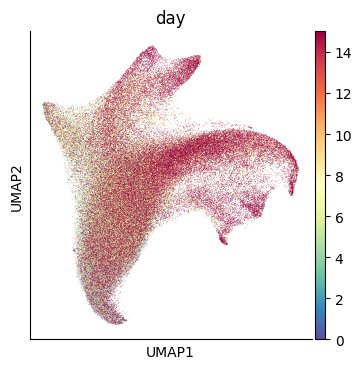

In [19]:
sc.pl.umap(ad4, color='day')

In [24]:
ad_atryi = sc.read_h5ad("/rds/project/rds-SDzz0CATGms/users/wz369/adata_UMAP_CellType_20250929.h5ad")

In [43]:
ad_atryi.obs['SITT']

AAACCCAAGCGACTTT-1_SLX26760_SITTA1-0      SITTA1
AAACCCAGTAGACACG-1_SLX26760_SITTA1-0      SITTA1
AAACCCAGTCTGCGCA-1_SLX26760_SITTA1-0      SITTA1
AAACGAAAGTAAGAGG-1_SLX26760_SITTA1-0      SITTA1
AAACGAAAGTATAGGT-1_SLX26760_SITTA1-0      SITTA1
                                          ...   
TTTGTTGTCCATAGAC-1_SLX26760_SITTH11-8    SITTH11
TTTGTTGTCCATCAGA-1_SLX26760_SITTH11-8    SITTH11
TTTGTTGTCCTGTAGA-1_SLX26760_SITTH11-8    SITTH11
TTTGTTGTCTCATGGA-1_SLX26760_SITTH11-8    SITTH11
TTTGTTGTCTGCCTGT-1_SLX26760_SITTH11-8    SITTH11
Name: SITT, Length: 142180, dtype: category
Categories (9, object): ['SITTA1', 'SITTB1', 'SITTC1', 'SITTD10', ..., 'SITTF1', 'SITTF11', 'SITTG11', 'SITTH11']

In [25]:
ad_atryi

AnnData object with n_obs × n_vars = 142180 × 33696
    obs: 'library', 'dataset', 'day', 'rep', 'batch', 'n_genes', 'n_counts', 'percent_mito', 'doublet_score', 'phase', 'S_score', 'G2M_score', 'cell_barcode', 'SITT', 'key', 'LARRY_barcode', 'HSC_score', 'top_1_hsc_score', 'low_hsc_score', 'leiden', 'leiden_1', 'RepopSig_score', 'RepopSig_score_z', 'LEIDEN', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'isCC', 'mean', 'std'
    uns: 'LEIDEN_colors', 'RepopSig_genes_missing', 'RepopSig_genes_used', 'batch_colors', 'cell_type_colors', 'hvg', 'leiden', 'leiden_1_colors', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'phase_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'log_counts', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [ ]:
ad_atryi.obs['day'].unique()
ad_atryi.obs['Day'] = ad_atryi.obs['day'].astype(str)

array([ 0,  5, 12, 21, 28])

In [38]:
ad_atryi.var_names

Index(['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587',
       'Gm37323', 'Mrpl15', 'A930006A01Rik',
       ...
       'Gm16367', 'ENSMUSG00000094172', 'ENSMUSG00000094887',
       'ENSMUSG00000091585', 'ENSMUSG00000095763', 'ENSMUSG00000095523',
       'ENSMUSG00000095475', 'ENSMUSG00000094855', 'ENSMUSG00000095019',
       'ENSMUSG00000095041'],
      dtype='object', length=33696)

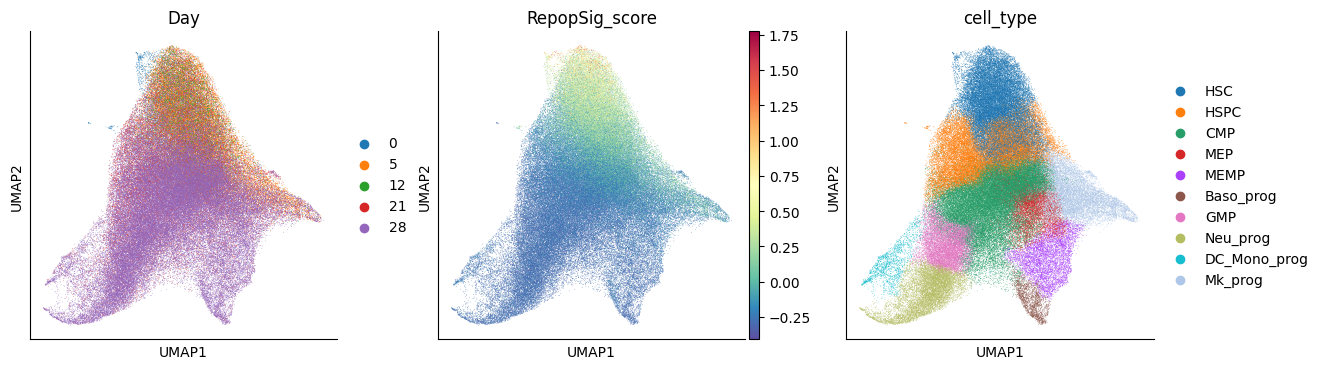

In [33]:
sc.pl.umap(ad_atryi, color=['Day', 'RepopSig_score', 'cell_type'])

In [15]:
ad5 = sc.read_h5ad("data/adata_no_d20_regress_phase_harmony_1000_10_30_20250516_cell_type_new_metaclone_d3HSC.h5ad")
ad5

AnnData object with n_obs × n_vars = 47150 × 33696
    obs: 'library', 'dataset', 'Condition', 'batch', 'day', 'n_genes', 'n_counts', 'percent_mito', 'doublet_score', 'cell_barcode', 'LARRY_barcode', 'Day', 'phase', 'S_score', 'G2M_score', 'leiden', 'LEIDEN', 'cell_type', 'metaclone', 'condition', 'metaclone_original'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'isCC', 'mean', 'std'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_rotated'
    layers: 'log_counts', 'raw_counts'

In [37]:
ad5.var_names

Index(['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587',
       'Gm37323', 'Mrpl15', 'A930006A01Rik',
       ...
       'Gm16367', 'ENSMUSG00000094172', 'ENSMUSG00000094887',
       'ENSMUSG00000091585', 'ENSMUSG00000095763', 'ENSMUSG00000095523',
       'ENSMUSG00000095475', 'ENSMUSG00000094855', 'ENSMUSG00000095019',
       'ENSMUSG00000095041'],
      dtype='object', length=33696)

In [16]:
ad6 = sc.read_h5ad("data/ad.h5ad")
ad6

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

# Weinreb

In [76]:
ad2 = sc.read_h5ad("data/Complete_LARRY_dataset_adata_preprocessed.h5ad")

In [77]:
ad2.var_names

Index(['0610006L08Rik', '0610007P14Rik', '0610009B22Rik', '0610009E02Rik',
       '0610009L18Rik', '0610009O20Rik', '0610010F05Rik', '0610010K14Rik',
       '0610011F06Rik', '0610012D04Rik',
       ...
       'mt-Co2', 'mt-Co3', 'mt-Cytb', 'mt-Nd1', 'mt-Nd2', 'mt-Nd3', 'mt-Nd4',
       'mt-Nd4l', 'mt-Nd5', 'mt-Nd6'],
      dtype='object', name='index', length=25289)

In [48]:
ad_weinreb = sc.read_h5ad("data/weineb_invitro.h5ad")
ad_weinreb

AnnData object with n_obs × n_vars = 130887 × 2447
    obs: 'Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'fate_observed', 't0_fated', 'train', 'test'
    obsm: 'X_pca', 'X_umap'
    layers: 'X_scaled'

In [75]:
ad_weinreb.var_names

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '2437', '2438', '2439', '2440', '2441', '2442', '2443', '2444', '2445',
       '2446'],
      dtype='object', length=2447)

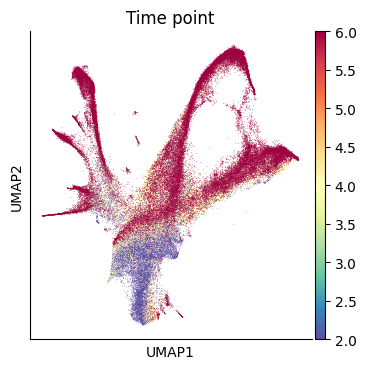

In [55]:
sc.pl.umap(ad_weinreb, color='Time point')

In [64]:
ad_in_vivo = sc.read_h5ad("data/tissue_adata_refined_20221106_joint.h5ad")
ad_in_vivo


AnnData object with n_obs × n_vars = 10802 × 21406
    obs: 'library', 'batch', 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type', 'state_info', 'time_info', 'tissue', 'state_info_old'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable'
    uns: 'cell_type_colors', 'clonal_time_points', 'clone_id', 'data_des', 'library_colors', 'neighbors', 'scrublet', 'state_info_colors', 'time_ordering', 'tissue_colors', 'umap'
    obsm: 'X_clone', 'X_emb', 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [69]:
ad_in_vivo[ad_in_vivo.obs['tissue'] == "Skull"]

View of AnnData object with n_obs × n_vars = 6121 × 21406
    obs: 'library', 'batch', 'n_genes', 'n_counts', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'cell_type', 'state_info', 'time_info', 'tissue', 'state_info_old'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable'
    uns: 'cell_type_colors', 'clonal_time_points', 'clone_id', 'data_des', 'library_colors', 'neighbors', 'scrublet', 'time_ordering', 'tissue_colors', 'umap', 'time_info_colors'
    obsm: 'X_clone', 'X_emb', 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [74]:
ad_in_vivo.obsm['X_clone'].shape

(10802, 2081)

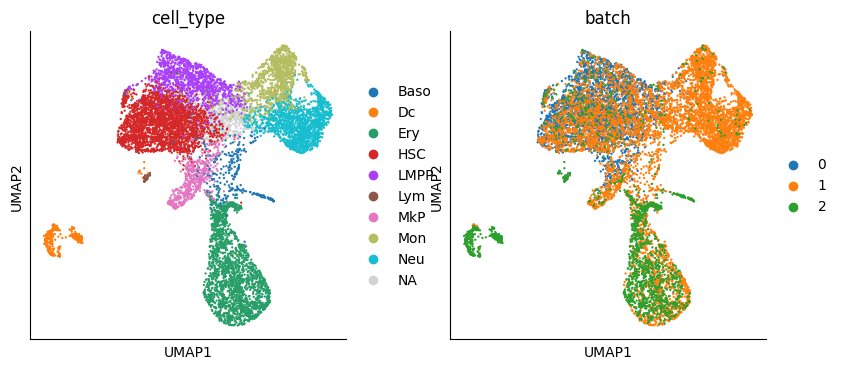

In [71]:
sc.pl.umap(ad_in_vivo, color=['cell_type', 'batch'])